# 전통적 머신러닝(ML) 분류 모델 실험

## 노트북 목적
이 노트북은 **2,080개 한국어 동료 피드백 텍스트**를 7단계 척도(0~6)로 자동 분류하기 위해 **14개 전통적 ML 모델**(11개 단일 + 3개 앙상블)을 체계적으로 비교합니다.

### 핵심 개념 설명
- **TF-IDF(Term Frequency-Inverse Document Frequency)**: 텍스트를 숫자 벡터로 변환하는 방법. 문서에서 자주 등장하지만 전체 문서에서는 드문 단어에 높은 가중치를 부여
- **교차 검증(Cross-Validation)**: 데이터를 여러 부분으로 나누어 모델을 반복 평가하는 기법. 과적합(Overfitting)을 방지하고 모델의 일반화 성능을 추정
- **Cohen's Kappa**: 두 평가자 간의 일치도를 우연에 의한 일치를 보정하여 측정하는 지표 (0=우연 수준, 1=완벽 일치)
- **F1 Score (Macro)**: 정밀도(Precision)와 재현율(Recall)의 조화 평균. Macro는 모든 클래스에 동일한 가중치를 부여

### 실험 설계
| 요소 | 내용 |
|------|------|
| 데이터 | 3개 seed (42, 43, 44)로 분할 (Train 80% / Test 20%) |
| 벡터화 | V1(Word TF-IDF), V2(Char TF-IDF), V3(Chi-square 특성 선택) |
| 분류기 | 11개 단일 모델 + 3개 앙상블(Ensemble) = 14개 |
| 총 조합 | 3 seeds x 3 벡터화 x 14 분류기 = **126개 실험** |
| 검증 | Stratified 10-Fold CV + 재현성 테스트 + 일반화 테스트 |

# ML 분류 모델 재현성 및 일반화 실험

## 실험 목적
1. **학습 안정성**: Stratified 10-Fold CV로 모델 성능의 분산 측정
2. **재현성(Reproducibility)**: 동일 모델로 동일 데이터를 3회 예측했을 때 결과가 일치하는가?
3. **일반화(Generalization)**: 다른 데이터 split에서도 유사한 성능을 보이는가?

## 실험 설계
- **데이터**: 3개 seed (42, 43, 44)로 분할된 train/test 파일
- **학습 방식**: Stratified 10-Fold Cross-Validation
- **벡터화**: V1(Word TF-IDF), V2(Char TF-IDF), V3(Chi-square)
- **분류기**: 11개 단일 + 3개 앙상블 = 14개
- **총 조합**: 3 seeds × 3 벡터화 × 14 분류기 = 126개

## 워크플로우
```
각 (seed, vectorization, classifier) 조합에 대해:
1. Stratified 10-Fold CV 수행 → CV 성능 (mean ± std)
2. 전체 Train set으로 최종 모델 학습
3. Same seed Test set 평가 + 재현성 테스트 (3회 예측)
4. Other seed Test set 평가 (일반화 테스트)
```

---
## 1. 환경 설정

아래 셀에서는 실험에 필요한 모든 Python 라이브러리를 불러옵니다.
- **kiwipiepy**: 한국어 형태소 분석기 (텍스트를 의미 단위로 분리)
- **scikit-learn**: ML 알고리즘과 평가 도구 모음
- **xgboost, lightgbm**: 고성능 그래디언트 부스팅 라이브러리
- **tqdm**: 실험 진행률을 시각적으로 보여주는 진행 막대

In [29]:
# 필요시 설치 (주석 해제 후 실행)
#!pip install kiwipiepy pandas numpy scikit-learn xgboost lightgbm matplotlib seaborn openpyxl

In [30]:
# 기본 라이브러리
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
import os
import platform
from datetime import datetime
from copy import deepcopy
import json
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

# 한국어 형태소 분석기
from kiwipiepy import Kiwi

# 전처리 및 벡터화
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import LabelEncoder

# 분류 알고리즘
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, 
    GradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Cross-validation
from sklearn.model_selection import StratifiedKFold, cross_val_score

# 평가
from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    cohen_kappa_score,
    classification_report,
    confusion_matrix
)

# 한글 폰트 설정
if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False

# 결과 저장 디렉토리
OUTPUT_DIR = './results/final_experiment'
os.makedirs(f'{OUTPUT_DIR}/reproducibility', exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/generalization', exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/models', exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/summary', exist_ok=True)

print(f"운영체제: {platform.system()}")
print(f"실험 시작: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("라이브러리 로드 완료!")

운영체제: Darwin
실험 시작: 2026-01-28 16:57:14
라이브러리 로드 완료!


---
## 2. 데이터 로드

3개의 서로 다른 랜덤 시드(42, 43, 44)로 데이터를 분할하여 **결과의 안정성**을 확인합니다.
각 시드마다 동일한 80:20 비율로 학습/테스트 세트를 나눕니다.

- **Seed(시드)**: 랜덤 분할의 초기값. 같은 시드를 사용하면 동일한 분할을 재현할 수 있음
- **Stratified Split**: 각 클래스(0~6)의 비율이 학습/테스트 세트에서 동일하게 유지되도록 분할

In [31]:
# 데이터 경로 설정
DATA_PATH = '../data/feedback_data.xlsx'
SEEDS = [42, 43, 44]

# 컬럼명 설정
TEXT_COLUMN = 'feedback_text'
LABEL_COLUMN = 'label'

# 데이터 로드
datasets = {}
for seed in SEEDS:
    all_df = pd.read_excel(DATA_PATH)  # data/feedback_data.xlsx (main 시트)
    train_df = all_df[all_df[f'split_seed{seed}'] == 'train'].reset_index(drop=True)
    test_df = all_df[all_df[f'split_seed{seed}'] == 'test'].reset_index(drop=True)
    
    datasets[seed] = {
        'train': train_df,
        'test': test_df
    }
    
    print(f"Seed {seed}: Train={train_df.shape}, Test={test_df.shape}")

print(f"\n컬럼: {datasets[42]['train'].columns.tolist()}")

Seed 42: Train=(1664, 3), Test=(416, 3)
Seed 43: Train=(1664, 3), Test=(416, 3)
Seed 44: Train=(1664, 3), Test=(416, 3)

컬럼: ['id', 'feedback_text', 'label']


### 레이블 분포 확인
학습 데이터와 테스트 데이터에서 각 피드백 수준(0~6)의 분포가 균등하게 유지되는지 확인합니다.
불균형한 분포는 모델 학습에 영향을 줄 수 있으므로 사전에 파악해야 합니다.

In [32]:
# 데이터 분포 확인
print("="*60)
print("Label 분포 비교")
print("="*60)

for seed in SEEDS:
    train_dist = datasets[seed]['train'][LABEL_COLUMN].value_counts().sort_index()
    test_dist = datasets[seed]['test'][LABEL_COLUMN].value_counts().sort_index()
    print(f"\nSeed {seed}:")
    print(f"  Train: {dict(train_dist)}")
    print(f"  Test:  {dict(test_dist)}")

Label 분포 비교

Seed 42:
  Train: {0: 48, 1: 410, 2: 228, 3: 585, 4: 145, 5: 222, 6: 26}
  Test:  {0: 12, 1: 103, 2: 57, 3: 146, 4: 36, 5: 55, 6: 7}

Seed 43:
  Train: {0: 48, 1: 410, 2: 228, 3: 585, 4: 145, 5: 222, 6: 26}
  Test:  {0: 12, 1: 103, 2: 57, 3: 146, 4: 36, 5: 55, 6: 7}

Seed 44:
  Train: {0: 48, 1: 410, 2: 228, 3: 585, 4: 145, 5: 222, 6: 26}
  Test:  {0: 12, 1: 103, 2: 57, 3: 146, 4: 36, 5: 55, 6: 7}


---
## 3. 형태소 처리 (Kiwi + Lemmatization)

### 형태소 분석이란?
한국어는 영어와 달리 공백만으로 단어를 구분하기 어렵습니다. 예를 들어 '좋았습니다'를 '좋-' (형용사 어근) + '-았-' (과거 시제) + '-습니다' (존칭)로 분리해야 합니다.

**Kiwi 형태소 분석기**를 사용하여:
1. 텍스트를 형태소 단위로 분리
2. 명사(N), 동사(V), 형용사(VA), 부사(MAG) 등 의미 있는 품사만 추출
3. **레마타이제이션(Lemmatization)**: 활용된 형태를 원형으로 복원 (예: '좋았다' → '좋다')

In [33]:
class KiwiLemmaTokenizer:
    """
    Kiwi 형태소 분석기 + Lemmatization
    
    품사 필터링: N(명사), V(동사), Adj(형용사), Adv(부사)
    원형 복원: token.lemma 속성 사용
    """
    
    INCLUDE_POS = {  # 추출할 품사 태그 집합
        'NNG', 'NNP', 'NNB', 'NR',  # 명사류: 일반명사, 고유명사, 의존명사, 수사  # 명사류
        'VV', 'VA', 'VX',  # 동사, 형용사, 보조용언            # 용언류
        'MAG', 'MAJ',  # 일반부사, 접속부사                # 부사류
    }
    
    def __init__(self):
        self.kiwi = Kiwi()
        print("Kiwi 형태소 분석기 초기화 완료")
    
    def tokenize_with_lemma(self, text):
        """텍스트를 토큰화하고 원형(lemma)으로 변환"""
        if pd.isna(text) or str(text).strip() == '':
            return ''
        
        text = str(text)
        tokens = self.kiwi.tokenize(text)
        
        lemmas = []
        for token in tokens:
            if token.tag in self.INCLUDE_POS:
                lemma = token.lemma if token.lemma else token.form  # 원형(lemma)이 있으면 사용, 없으면 표층형(form) 사용
                lemmas.append(lemma)
        
        return ' '.join(lemmas)

# 토크나이저 초기화
tokenizer = KiwiLemmaTokenizer()

Kiwi 형태소 분석기 초기화 완료


Quantization is not supported for ArchType::neon. Fall back to non-quantized model.


In [34]:
# 전체 데이터 토큰화
print("전체 데이터 토큰화 중...")

for seed in SEEDS:
    print(f"  Seed {seed}...", end=' ')
    datasets[seed]['train']['tokenized'] = datasets[seed]['train'][TEXT_COLUMN].apply(
        tokenizer.tokenize_with_lemma
    )
    datasets[seed]['test']['tokenized'] = datasets[seed]['test'][TEXT_COLUMN].apply(
        tokenizer.tokenize_with_lemma
    )
    print("완료")

print("\n토큰화 완료!")

전체 데이터 토큰화 중...
  Seed 42... 완료
  Seed 43... 완료
  Seed 44... 완료

토큰화 완료!


---
## 4. 벡터화 및 분류기 정의

### 텍스트 벡터화 전략
ML 모델은 숫자만 처리할 수 있으므로, 텍스트를 숫자 벡터로 변환해야 합니다.

3가지 벡터화 방법을 비교합니다:
- **V1_Word**: 단어 단위 TF-IDF (형태소 분석 결과 사용, 1~2-gram)
- **V2_Char**: 문자 단위 TF-IDF (원문 사용, 3~5-gram) - 오타나 신조어에 강건
- **V3_Chi2**: V1 + 카이제곱(Chi-square) 특성 선택 - 가장 판별력 높은 5,000개 특성만 사용

> **N-gram**: 연속된 N개의 토큰. 예를 들어 '좋은 의견'이라는 텍스트에서 1-gram은 ['좋은', '의견'], 2-gram은 ['좋은 의견']

In [35]:
def custom_tokenizer(text):
    """이미 토큰화된 텍스트를 공백으로 분리"""
    return text.split() if text else []

def identity_preprocessor(text):
    """전처리 없이 텍스트 그대로 반환"""
    return text

def create_vectorizers():
    """벡터화 객체 생성 (매번 새로 생성해야 fit 가능)"""
    return {
        'V1_Word': TfidfVectorizer(
            tokenizer=custom_tokenizer,
            preprocessor=identity_preprocessor,
            ngram_range=(1, 2),  # 1-gram과 2-gram 모두 사용
            min_df=2,  # 최소 2개 문서에서 등장한 단어만 포함
            max_df=0.95,  # 95% 이상 문서에서 등장하는 단어는 제외 (불용어 효과)
            sublinear_tf=True  # TF에 로그 스케일링 적용 (빈도 편향 완화)
        ),
        'V2_Char': TfidfVectorizer(
            analyzer='char',  # 문자 단위 분석 (형태소 분석 불필요)
            ngram_range=(3, 5),  # 3~5개 연속 문자 조합
            min_df=2,
            max_df=0.95,
            sublinear_tf=True
        ),
        'V3_Chi2': TfidfVectorizer(
            tokenizer=custom_tokenizer,
            preprocessor=identity_preprocessor,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95,
            sublinear_tf=True
        )
    }

# Chi-square feature selection k값
V3_K = 5000

print("벡터화 전략:")
print("  V1_Word: Word TF-IDF (lemma, ngram 1-2)")
print("  V2_Char: Char TF-IDF (원문, char 3-5)")
print(f"  V3_Chi2: Word TF-IDF + Chi-square (k={V3_K})")

벡터화 전략:
  V1_Word: Word TF-IDF (lemma, ngram 1-2)
  V2_Char: Char TF-IDF (원문, char 3-5)
  V3_Chi2: Word TF-IDF + Chi-square (k=5000)


### 분류기(Classifier) 정의
11개 단일 모델과 3개 앙상블(Ensemble) 모델을 정의합니다.

**단일 모델 (11개):**
| 모델 | 약어 | 설명 |
|------|------|------|
| Logistic Regression | LR | 선형 분류의 기본 모델 |
| Linear SVM | SVM-L | 고차원 텍스트 데이터에 효과적인 서포트 벡터 머신 |
| RBF SVM | SVM-RBF | 비선형 커널을 사용한 SVM |
| Multinomial NB | MNB | 다항 나이브 베이즈 (텍스트 분류의 전통적 기법) |
| Complement NB | CNB | 불균형 데이터에 강한 나이브 베이즈 변형 |
| K-Nearest Neighbors | KNN | 가장 가까운 K개 이웃의 다수결로 분류 |
| Decision Tree | DT | 트리 구조로 규칙을 학습하는 모델 |
| Random Forest | RF | 여러 결정 트리의 다수결 (배깅 앙상블) |
| Gradient Boosting | GB | 순차적으로 트리를 추가하며 오류를 보정 |
| XGBoost | XGB | 최적화된 그래디언트 부스팅 |
| LightGBM | LGBM | 대규모 데이터에 최적화된 그래디언트 부스팅 |

**앙상블(Ensemble): 여러 모델의 예측을 결합하여 더 나은 성능을 얻는 방법**
- **Soft Voting**: 각 모델의 확률 예측을 평균하여 최종 결정
- **Stacking**: 기본 모델들의 예측을 새로운 모델(메타 학습기)의 입력으로 사용
- **Hard Voting**: 각 모델의 예측 결과 중 다수결로 최종 결정

In [36]:
def get_classifiers(random_state=42):
    """11개 단일 분류기 정의"""
    return {
        'LR': LogisticRegression(
            class_weight='balanced',  # 클래스 불균형을 자동 보정 (소수 클래스에 높은 가중치)
            max_iter=1000,
            random_state=random_state,
            n_jobs=-1  # 모든 CPU 코어 사용하여 병렬 학습
        ),
        'SVM-L': LinearSVC(
            class_weight='balanced',
            max_iter=2000,
            random_state=random_state
        ),
        'SVM-RBF': SVC(
            kernel='rbf',
            class_weight='balanced',
            random_state=random_state,
            probability=True
        ),
        'MNB': MultinomialNB(alpha=1.0),
        'CNB': ComplementNB(alpha=1.0),
        'KNN': KNeighborsClassifier(
            n_neighbors=5,
            weights='distance',
            n_jobs=-1
        ),
        'DT': DecisionTreeClassifier(
            class_weight='balanced',
            random_state=random_state
        ),
        'RF': RandomForestClassifier(
            n_estimators=100,
            class_weight='balanced',
            random_state=random_state,
            n_jobs=-1
        ),
        'GB': GradientBoostingClassifier(
            n_estimators=100,
            random_state=random_state
        ),
        'XGB': XGBClassifier(
            n_estimators=100,
            use_label_encoder=False,
            eval_metric='mlogloss',
            random_state=random_state,
            n_jobs=-1,
            verbosity=0
        ),
        'LGBM': LGBMClassifier(
            n_estimators=100,
            class_weight='balanced',
            random_state=random_state,
            n_jobs=-1,
            verbose=-1
        )
    }

def get_ensemble_classifiers(random_state=42):
    """3개 앙상블 분류기 정의"""
    base_estimators = [
        ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=random_state)),
        ('svm', LinearSVC(class_weight='balanced', max_iter=2000, random_state=random_state)),
        ('cnb', ComplementNB(alpha=1.0)),
        ('rf', RandomForestClassifier(n_estimators=50, class_weight='balanced', random_state=random_state, n_jobs=-1))
    ]
    
    base_estimators_soft = [
        ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=random_state)),
        ('svm', SVC(kernel='linear', class_weight='balanced', random_state=random_state, probability=True)),
        ('cnb', ComplementNB(alpha=1.0)),
        ('rf', RandomForestClassifier(n_estimators=50, class_weight='balanced', random_state=random_state, n_jobs=-1))
    ]
    
    return {
        'Hard Voting': VotingClassifier(
            estimators=base_estimators,
            voting='hard',
            n_jobs=-1
        ),
        'Soft Voting': VotingClassifier(
            estimators=base_estimators_soft,
            voting='soft',
            n_jobs=-1
        ),
        'Stacking': StackingClassifier(
            estimators=base_estimators_soft,
            final_estimator=LogisticRegression(class_weight='balanced', max_iter=1000, random_state=random_state),
            cv=5,
            n_jobs=-1
        )
    }

def get_all_classifiers(random_state=42):
    """모든 분류기 반환 (14개)"""
    clfs = get_classifiers(random_state)
    clfs.update(get_ensemble_classifiers(random_state))
    return clfs

print(f"총 분류기: {len(get_all_classifiers())}개")
print("단일:", list(get_classifiers().keys()))
print("앙상블:", list(get_ensemble_classifiers().keys()))

총 분류기: 14개
단일: ['LR', 'SVM-L', 'SVM-RBF', 'MNB', 'CNB', 'KNN', 'DT', 'RF', 'GB', 'XGB', 'LGBM']
앙상블: ['Hard Voting', 'Soft Voting', 'Stacking']


---
## 5. 실험 실행 함수 정의

### 실험 함수 설명
아래 함수들은 실험의 각 단계를 수행합니다:

1. **`prepare_data()`**: 텍스트를 벡터화하여 ML 모델이 처리할 수 있는 형태로 변환
2. **`run_reproducibility_test()`**: 동일 모델로 동일 데이터를 3회 예측하여 결과 일관성 확인
3. **`evaluate_predictions()`**: Accuracy, F1, Kappa 등 성능 지표 계산
4. **`run_stratified_cv()`**: Stratified 10-Fold 교차 검증 수행

> **Stratified K-Fold CV**: 데이터를 K개 폴드로 나누되, 각 폴드에서 클래스 비율이 전체와 동일하도록 유지. 불균형 데이터에서 특히 중요

In [37]:
def prepare_data(train_df, test_df, vec_name, vectorizer, y_train):
    """
    벡터화 수행 및 데이터 준비
    """
    if vec_name == 'V2_Char':
        # V2: 원문 사용
        X_train = vectorizer.fit_transform(train_df[TEXT_COLUMN].astype(str))
        X_test = vectorizer.transform(test_df[TEXT_COLUMN].astype(str))
    else:
        # V1, V3: 토큰화된 텍스트 사용
        X_train = vectorizer.fit_transform(train_df['tokenized'])
        X_test = vectorizer.transform(test_df['tokenized'])
    
    # V3: Chi-square feature selection
    if vec_name == 'V3_Chi2':
        actual_k = min(V3_K, X_train.shape[1])
        selector = SelectKBest(chi2, k=actual_k)  # 카이제곱 검정으로 가장 유의미한 k개 특성 선택
        X_train = selector.fit_transform(X_train, y_train)
        X_test = selector.transform(X_test)
        return X_train, X_test, (vectorizer, selector)
    
    return X_train, X_test, vectorizer

In [38]:
def run_reproducibility_test(clf, X_test, n_repeats=3):
    """
    재현성 테스트: 동일 데이터에 대해 n회 예측
    
    Returns:
        predictions: list of prediction arrays
        agreement_rate: 모든 예측이 일치하는 샘플 비율
        disagreement_indices: 불일치 샘플 인덱스
    """
    predictions = []
    
    for i in range(n_repeats):
        pred = clf.predict(X_test)
        predictions.append(pred)
    
    # 일치율 계산
    predictions_array = np.array(predictions)
    agreement = np.all(predictions_array == predictions_array[0], axis=0)  # 모든 반복에서 예측이 동일한 샘플 찾기
    agreement_rate = agreement.mean()
    disagreement_indices = np.where(~agreement)[0]
    
    return predictions, agreement_rate, disagreement_indices

In [39]:
def evaluate_predictions(y_true, y_pred):
    """
    예측 결과 평가
    """
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'F1_Macro': f1_score(y_true, y_pred, average='macro'),
        'F1_Weighted': f1_score(y_true, y_pred, average='weighted'),
        'Kappa': cohen_kappa_score(y_true, y_pred)
    }

In [40]:
def run_stratified_cv(clf, X_train, y_train, n_splits=10, random_state=42):
    """
    Stratified 10-Fold Cross-Validation 수행
    
    Args:
        clf: 분류기 객체
        X_train: 학습 데이터
        y_train: 학습 레이블
        n_splits: fold 수 (기본값 10)
        random_state: 랜덤 시드
    
    Returns:
        cv_results: dict with fold-wise scores and statistics
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    
    fold_results = {
        'accuracy': [],
        'f1_macro': [],
        'kappa': []
    }
    
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
        X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
        y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]
        
        # 분류기 복사 (각 fold마다 새로 학습)
        clf_copy = deepcopy(clf)  # 각 폴드마다 독립적인 모델 복사본 사용
        clf_copy.fit(X_fold_train, y_fold_train)
        
        # 예측 및 평가
        y_pred = clf_copy.predict(X_fold_val)
        
        fold_results['accuracy'].append(accuracy_score(y_fold_val, y_pred))
        fold_results['f1_macro'].append(f1_score(y_fold_val, y_pred, average='macro'))
        fold_results['kappa'].append(cohen_kappa_score(y_fold_val, y_pred))
    
    # 통계 계산
    cv_results = {
        'CV_Acc_Mean': np.mean(fold_results['accuracy']),
        'CV_Acc_Std': np.std(fold_results['accuracy']),
        'CV_F1_Mean': np.mean(fold_results['f1_macro']),
        'CV_F1_Std': np.std(fold_results['f1_macro']),
        'CV_Kappa_Mean': np.mean(fold_results['kappa']),
        'CV_Kappa_Std': np.std(fold_results['kappa']),
        'CV_Fold_Scores': fold_results
    }
    
    return cv_results

print("Stratified 10-Fold CV 함수 정의 완료")

Stratified 10-Fold CV 함수 정의 완료


---
## 6. 전체 실험 실행

### 메인 실험 루프
아래 코드는 126개 조합(3 seeds x 3 벡터화 x 14 분류기)을 순차적으로 실행합니다.

각 조합에 대해 다음을 수행합니다:
1. **Stratified 10-Fold CV** → 학습 안정성 평가 (평균 성능과 표준편차)
2. **전체 학습 데이터로 최종 모델 학습** → 테스트 세트 평가
3. **재현성 테스트** → 동일 테스트 데이터에 3회 반복 예측하여 결과 일치율 확인
4. **일반화 테스트** → 다른 seed의 테스트 세트로도 평가 (Cross-seed generalization)

> 참고: `n_jobs=-1` 설정으로 가능한 경우 **모든 CPU 코어를 활용**하여 병렬 학습합니다.

In [41]:
# 레이블 인코더 (전체 데이터에서 학습)
all_labels = pd.concat([datasets[s]['train'][LABEL_COLUMN] for s in SEEDS] + 
                       [datasets[s]['test'][LABEL_COLUMN] for s in SEEDS])
label_encoder = LabelEncoder()
label_encoder.fit(all_labels)

print(f"레이블 클래스: {label_encoder.classes_}")

레이블 클래스: [0 1 2 3 4 5 6]


In [42]:
# 결과 저장용 리스트
all_cv_results = []               # CV 결과 (NEW)
all_reproducibility_results = []  # 재현성 결과
all_generalization_results = []   # 일반화 결과
all_detailed_predictions = []     # 상세 예측 결과

# 벡터화 종류
VEC_NAMES = ['V1_Word', 'V2_Char', 'V3_Chi2']

# CV 설정
N_FOLDS = 10

print("="*70)
print("전체 실험 시작 (Stratified 10-Fold CV)")
print("="*70)
print(f"Seeds: {SEEDS}")
print(f"Vectorizations: {VEC_NAMES}")
print(f"Classifiers: {len(get_all_classifiers())}개")
print(f"CV Folds: {N_FOLDS}")
print(f"총 조합: {len(SEEDS) * len(VEC_NAMES) * len(get_all_classifiers())}개")
print("="*70)

전체 실험 시작 (Stratified 10-Fold CV)
Seeds: [42, 43, 44]
Vectorizations: ['V1_Word', 'V2_Char', 'V3_Chi2']
Classifiers: 14개
CV Folds: 10
총 조합: 126개


In [43]:
# 메인 실험 루프 (Stratified 10-Fold CV 적용)
# 전체 조합 수 계산
total_combinations = len(SEEDS) * len(VEC_NAMES) * len(get_all_classifiers())

# 전체 진행률 바
pbar_total = tqdm(total=total_combinations, desc="전체 진행률", position=0)

for train_seed in SEEDS:
    print(f"\n{'#'*70}")
    print(f"# Training Seed: {train_seed}")
    print(f"{'#'*70}")
    
    train_df = datasets[train_seed]['train']
    test_df_same = datasets[train_seed]['test']
    
    # 레이블 인코딩
    y_train = label_encoder.transform(train_df[LABEL_COLUMN])
    y_test_same = label_encoder.transform(test_df_same[LABEL_COLUMN])
    
    # 다른 seed의 test set
    other_seeds = [s for s in SEEDS if s != train_seed]  # 일반화 테스트를 위한 다른 seed 목록
    
    for vec_name in VEC_NAMES:
        print(f"\n{'='*60}")
        print(f"벡터화: {vec_name}")
        print(f"{'='*60}")
        
        # 새 벡터화 객체 생성
        vectorizers = create_vectorizers()
        vectorizer = vectorizers[vec_name]
        
        # 학습 데이터 벡터화
        X_train, X_test_same, vec_obj = prepare_data(
            train_df, test_df_same, vec_name, vectorizer, y_train
        )
        print(f"  X_train shape: {X_train.shape}")
        
        # 다른 test set 벡터화
        X_tests_other = {}
        y_tests_other = {}
        for other_seed in other_seeds:
            test_df_other = datasets[other_seed]['test']
            y_tests_other[other_seed] = label_encoder.transform(test_df_other[LABEL_COLUMN])
            
            if vec_name == 'V2_Char':
                X_tests_other[other_seed] = vec_obj.transform(test_df_other[TEXT_COLUMN].astype(str))
            elif vec_name == 'V3_Chi2':
                vec, selector = vec_obj
                X_temp = vec.transform(test_df_other['tokenized'])
                X_tests_other[other_seed] = selector.transform(X_temp)
            else:
                X_tests_other[other_seed] = vec_obj.transform(test_df_other['tokenized'])
        
        # 분류기 순회 (tqdm 적용)
        classifiers = get_all_classifiers(random_state=train_seed)
        
        for clf_name, clf in tqdm(classifiers.items(), 
                                   desc=f"Seed{train_seed}/{vec_name}", 
                                   leave=False,
                                   position=1):
            
            try:
                # ===== NEW: Stratified 10-Fold CV =====
                cv_results = run_stratified_cv(
                    clf, X_train, y_train, 
                    n_splits=N_FOLDS, 
                    random_state=train_seed
                )
                
                cv_record = {
                    'Train_Seed': train_seed,
                    'Vectorization': vec_name,
                    'Classifier': clf_name,
                    'CV_Acc_Mean': cv_results['CV_Acc_Mean'],
                    'CV_Acc_Std': cv_results['CV_Acc_Std'],
                    'CV_F1_Mean': cv_results['CV_F1_Mean'],
                    'CV_F1_Std': cv_results['CV_F1_Std'],
                    'CV_Kappa_Mean': cv_results['CV_Kappa_Mean'],
                    'CV_Kappa_Std': cv_results['CV_Kappa_Std']
                }
                all_cv_results.append(cv_record)
                
                # ===== 전체 Train으로 최종 모델 학습 =====
                clf_final = deepcopy(clf)
                clf_final.fit(X_train, y_train)
                
                # ===== A. 재현성 테스트 =====
                predictions, agreement_rate, disagreement_idx = run_reproducibility_test(
                    clf_final, X_test_same, n_repeats=3
                )
                
                # 첫 번째 예측으로 성능 평가
                metrics_same = evaluate_predictions(y_test_same, predictions[0])
                
                rep_result = {
                    'Train_Seed': train_seed,
                    'Vectorization': vec_name,
                    'Classifier': clf_name,
                    'Test_Seed': train_seed,
                    'Agreement_Rate': agreement_rate,
                    'Disagreement_Count': len(disagreement_idx),
                    # CV 결과 포함
                    'CV_Acc_Mean': cv_results['CV_Acc_Mean'],
                    'CV_Acc_Std': cv_results['CV_Acc_Std'],
                    'CV_F1_Mean': cv_results['CV_F1_Mean'],
                    'CV_F1_Std': cv_results['CV_F1_Std'],
                    # Test 결과
                    **metrics_same
                }
                all_reproducibility_results.append(rep_result)
                
                # 상세 예측 저장
                for rep_idx, pred in enumerate(predictions):
                    detailed = {
                        'Train_Seed': train_seed,
                        'Vectorization': vec_name,
                        'Classifier': clf_name,
                        'Test_Seed': train_seed,
                        'Repetition': rep_idx + 1,
                        'Predictions': pred.tolist()
                    }
                    all_detailed_predictions.append(detailed)
                
                # ===== B. 일반화 테스트 =====
                for other_seed in other_seeds:
                    y_pred_other = clf_final.predict(X_tests_other[other_seed])
                    metrics_other = evaluate_predictions(y_tests_other[other_seed], y_pred_other)
                    
                    gen_result = {
                        'Train_Seed': train_seed,
                        'Vectorization': vec_name,
                        'Classifier': clf_name,
                        'Test_Seed': other_seed,
                        **metrics_other
                    }
                    all_generalization_results.append(gen_result)
                    
                    # 상세 예측 저장
                    detailed = {
                        'Train_Seed': train_seed,
                        'Vectorization': vec_name,
                        'Classifier': clf_name,
                        'Test_Seed': other_seed,
                        'Repetition': 1,
                        'Predictions': y_pred_other.tolist()
                    }
                    all_detailed_predictions.append(detailed)
                
                # 진행률 업데이트
                pbar_total.update(1)
                pbar_total.set_postfix({
                    'clf': clf_name, 
                    'cv_f1': f"{cv_results['CV_F1_Mean']:.3f}",
                    'test_acc': f"{metrics_same['Accuracy']:.3f}"
                })
                
            except Exception as e:
                print(f"  {clf_name} 오류: {e}")
                pbar_total.update(1)
                continue

pbar_total.close()
print("\n" + "="*70)
print("전체 실험 완료! (Stratified 10-Fold CV)")
print("="*70)

전체 진행률:   0%|          | 0/126 [00:00<?, ?it/s]


######################################################################
# Training Seed: 42
######################################################################

벡터화: V1_Word
  X_train shape: (1664, 991)


전체 진행률:  11%|█         | 14/126 [01:47<21:41, 11.62s/it, clf=Stacking, cv_f1=0.747, test_acc=0.839]   


벡터화: V2_Char
  X_train shape: (1664, 7165)


전체 진행률:  22%|██▏       | 28/126 [05:07<38:09, 23.36s/it, clf=Stacking, cv_f1=0.692, test_acc=0.798]   

...


벡터화: V2_Char
  X_train shape: (1664, 7115)


전체 진행률:  89%|████████▉ | 112/126 [17:44<05:00, 21.47s/it, clf=Stacking, cv_f1=0.704, test_acc=0.767]   


벡터화: V3_Chi2
  X_train shape: (1664, 980)


전체 진행률: 100%|██████████| 126/126 [19:13<00:00,  9.15s/it, clf=Stacking, cv_f1=0.741, test_acc=0.856]   


전체 실험 완료! (Stratified 10-Fold CV)


---
## 7. 결과 저장

In [44]:
# DataFrame 변환
cv_df = pd.DataFrame(all_cv_results)
reproducibility_df = pd.DataFrame(all_reproducibility_results)
generalization_df = pd.DataFrame(all_generalization_results)

print(f"CV 결과: {cv_df.shape}")
print(f"재현성 결과: {reproducibility_df.shape}")
print(f"일반화 결과: {generalization_df.shape}")

CV 결과: (126, 9)
재현성 결과: (126, 14)
일반화 결과: (252, 8)


In [45]:
# CSV 저장
cv_df.to_csv(f'{OUTPUT_DIR}/summary/cv_results.csv', index=False)
reproducibility_df.to_csv(f'{OUTPUT_DIR}/summary/reproducibility_results.csv', index=False)
generalization_df.to_csv(f'{OUTPUT_DIR}/summary/generalization_results.csv', index=False)

# 상세 예측 결과 저장 (JSON)
with open(f'{OUTPUT_DIR}/summary/detailed_predictions.json', 'w') as f:
    json.dump(all_detailed_predictions, f)

print("결과 파일 저장 완료:")
print(f"  - {OUTPUT_DIR}/summary/cv_results.csv  (★ Stratified 10-Fold CV)")
print(f"  - {OUTPUT_DIR}/summary/reproducibility_results.csv")
print(f"  - {OUTPUT_DIR}/summary/generalization_results.csv")
print(f"  - {OUTPUT_DIR}/summary/detailed_predictions.json")

결과 파일 저장 완료:
  - ./results/final_experiment/summary/cv_results.csv  (★ Stratified 10-Fold CV)
  - ./results/final_experiment/summary/reproducibility_results.csv
  - ./results/final_experiment/summary/generalization_results.csv
  - ./results/final_experiment/summary/detailed_predictions.json


---
## 8. Cross-Validation 분석

### CV 성능 시각화
히트맵을 통해 각 벡터화-분류기 조합의 교차 검증 성능을 한눈에 비교합니다.
색이 진할수록(빨간색에 가까울수록) F1 Macro 성능이 높습니다.

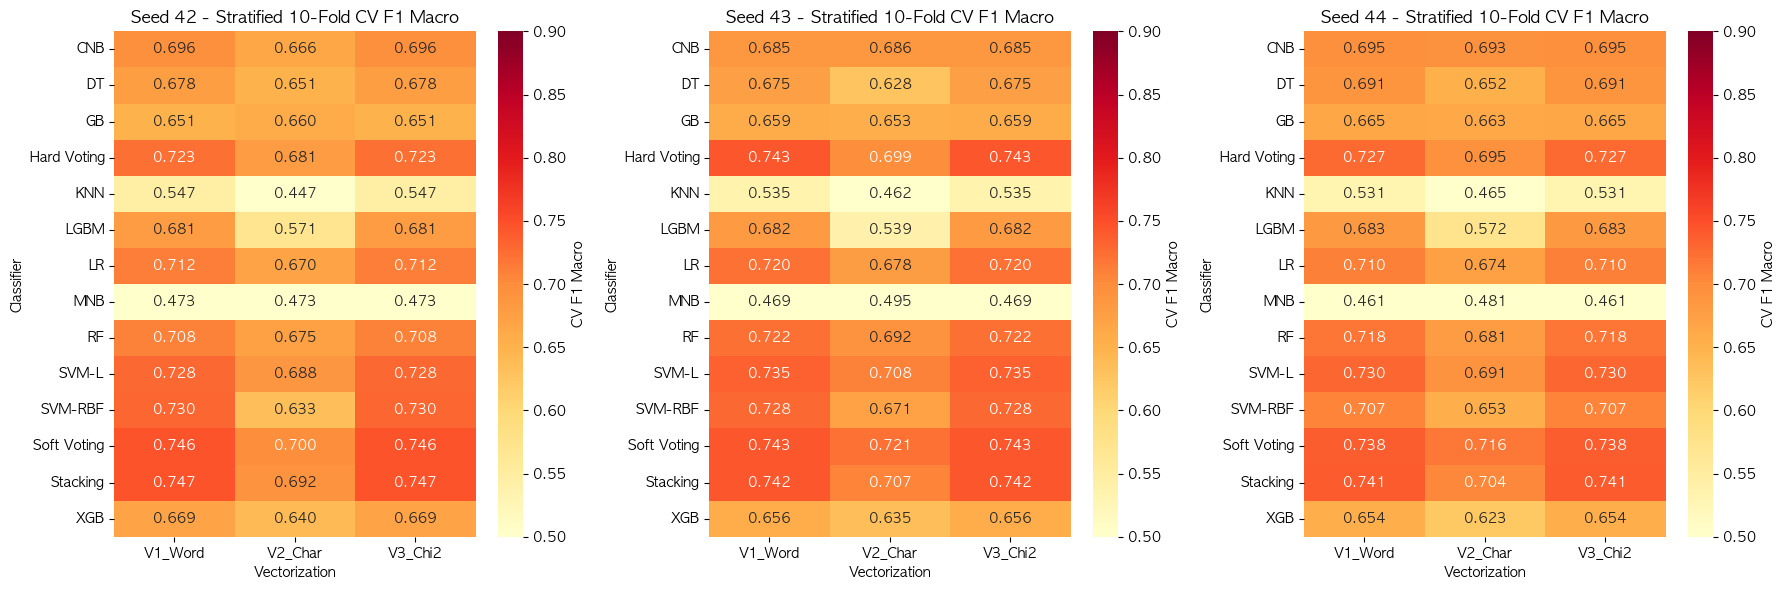

In [46]:
# CV 성능 히트맵
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, train_seed in enumerate(SEEDS):
    subset = cv_df[cv_df['Train_Seed'] == train_seed]
    pivot = subset.pivot(index='Classifier', columns='Vectorization', values='CV_F1_Mean')
    
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd', vmin=0.5, vmax=0.9,
                ax=axes[idx], cbar_kws={'label': 'CV F1 Macro'})
    axes[idx].set_title(f'Seed {train_seed} - Stratified 10-Fold CV F1 Macro')
    axes[idx].set_xlabel('Vectorization')
    axes[idx].set_ylabel('Classifier')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/summary/cv_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [47]:
# Cross-Validation 결과 분석
print("="*70)
print("Stratified 10-Fold Cross-Validation 분석")
print("="*70)

# CV 결과 요약
print(f"\n[전체 CV 통계]")
print(f"  CV Accuracy Mean: {cv_df['CV_Acc_Mean'].mean():.4f} (±{cv_df['CV_Acc_Std'].mean():.4f})")
print(f"  CV F1 Macro Mean: {cv_df['CV_F1_Mean'].mean():.4f} (±{cv_df['CV_F1_Std'].mean():.4f})")
print(f"  CV Kappa Mean:    {cv_df['CV_Kappa_Mean'].mean():.4f} (±{cv_df['CV_Kappa_Std'].mean():.4f})")

# 분류기별 CV 성능
print(f"\n[분류기별 CV 성능 (F1 Macro 기준)]")
clf_cv = cv_df.groupby('Classifier').agg({
    'CV_Acc_Mean': 'mean',
    'CV_Acc_Std': 'mean',
    'CV_F1_Mean': 'mean',
    'CV_F1_Std': 'mean',
    'CV_Kappa_Mean': 'mean'
}).round(4).sort_values('CV_F1_Mean', ascending=False)
print(clf_cv.to_string())

# 벡터화별 CV 성능
print(f"\n[벡터화별 CV 성능]")
vec_cv = cv_df.groupby('Vectorization').agg({
    'CV_Acc_Mean': 'mean',
    'CV_F1_Mean': 'mean',
    'CV_Kappa_Mean': 'mean'
}).round(4).sort_values('CV_F1_Mean', ascending=False)
print(vec_cv.to_string())

Stratified 10-Fold Cross-Validation 분석

[전체 CV 통계]
  CV Accuracy Mean: 0.7880 (±0.0240)
  CV F1 Macro Mean: 0.6639 (±0.0453)
  CV Kappa Mean:    0.7270 (±0.0307)

[분류기별 CV 성능 (F1 Macro 기준)]
             CV_Acc_Mean  CV_Acc_Std  CV_F1_Mean  CV_F1_Std  CV_Kappa_Mean
Classifier                                                                
Soft Voting       0.8221      0.0246      0.7320     0.0435         0.7734
Stacking          0.8181      0.0289      0.7290     0.0473         0.7702
SVM-L             0.8199      0.0255      0.7194     0.0401         0.7707
Hard Voting       0.8086      0.0264      0.7178     0.0459         0.7569
RF                0.8056      0.0227      0.7048     0.0481         0.7524
LR                0.7864      0.0261      0.7009     0.0456         0.7317
SVM-RBF           0.8066      0.0229      0.6986     0.0482         0.7542
CNB               0.7875      0.0221      0.6887     0.0395         0.7280
DT                0.7742      0.0236      0.6687     0.0482 

**결과 해석:** 교차 검증 결과에서 벡터화 방법(V1, V2, V3)과 분류기 조합별 성능 차이를 확인합니다.
CV 평균이 높고 표준편차가 낮은 조합이 가장 안정적이고 신뢰할 수 있는 모델입니다.

---
## 9. 재현성 분석

### 재현성(Reproducibility) 분석
동일한 학습 모델로 동일한 테스트 데이터를 3회 반복 예측했을 때, 예측 결과가 얼마나 일관적인지 확인합니다.

- **일치율 100%**: 매번 동일한 예측 (SVM, 로지스틱 회귀 등 결정적 모델)
- **일치율 < 100%**: 예측이 달라지는 경우 (랜덤 요소가 있는 모델)

높은 재현성은 연구 결과의 신뢰성을 보장합니다.

In [48]:
# 재현성 요약
print("="*70)
print("재현성 분석 결과")
print("="*70)

# 전체 재현성 통계
print(f"\n[전체 통계]")
print(f"  평균 일치율: {reproducibility_df['Agreement_Rate'].mean():.4f}")
print(f"  최소 일치율: {reproducibility_df['Agreement_Rate'].min():.4f}")
print(f"  최대 일치율: {reproducibility_df['Agreement_Rate'].max():.4f}")

# 분류기별 재현성
print(f"\n[분류기별 평균 일치율]")
clf_reproducibility = reproducibility_df.groupby('Classifier')['Agreement_Rate'].mean().sort_values(ascending=False)
print(clf_reproducibility.to_string())

재현성 분석 결과

[전체 통계]
  평균 일치율: 1.0000
  최소 일치율: 1.0000
  최대 일치율: 1.0000

[분류기별 평균 일치율]
Classifier
CNB            1.0
DT             1.0
GB             1.0
Hard Voting    1.0
KNN            1.0
LGBM           1.0
LR             1.0
MNB            1.0
RF             1.0
SVM-L          1.0
SVM-RBF        1.0
Soft Voting    1.0
Stacking       1.0
XGB            1.0


In [49]:
# 벡터화별 재현성
print(f"\n[벡터화별 평균 일치율]")
vec_reproducibility = reproducibility_df.groupby('Vectorization')['Agreement_Rate'].mean().sort_values(ascending=False)
print(vec_reproducibility.to_string())


[벡터화별 평균 일치율]
Vectorization
V1_Word    1.0
V2_Char    1.0
V3_Chi2    1.0


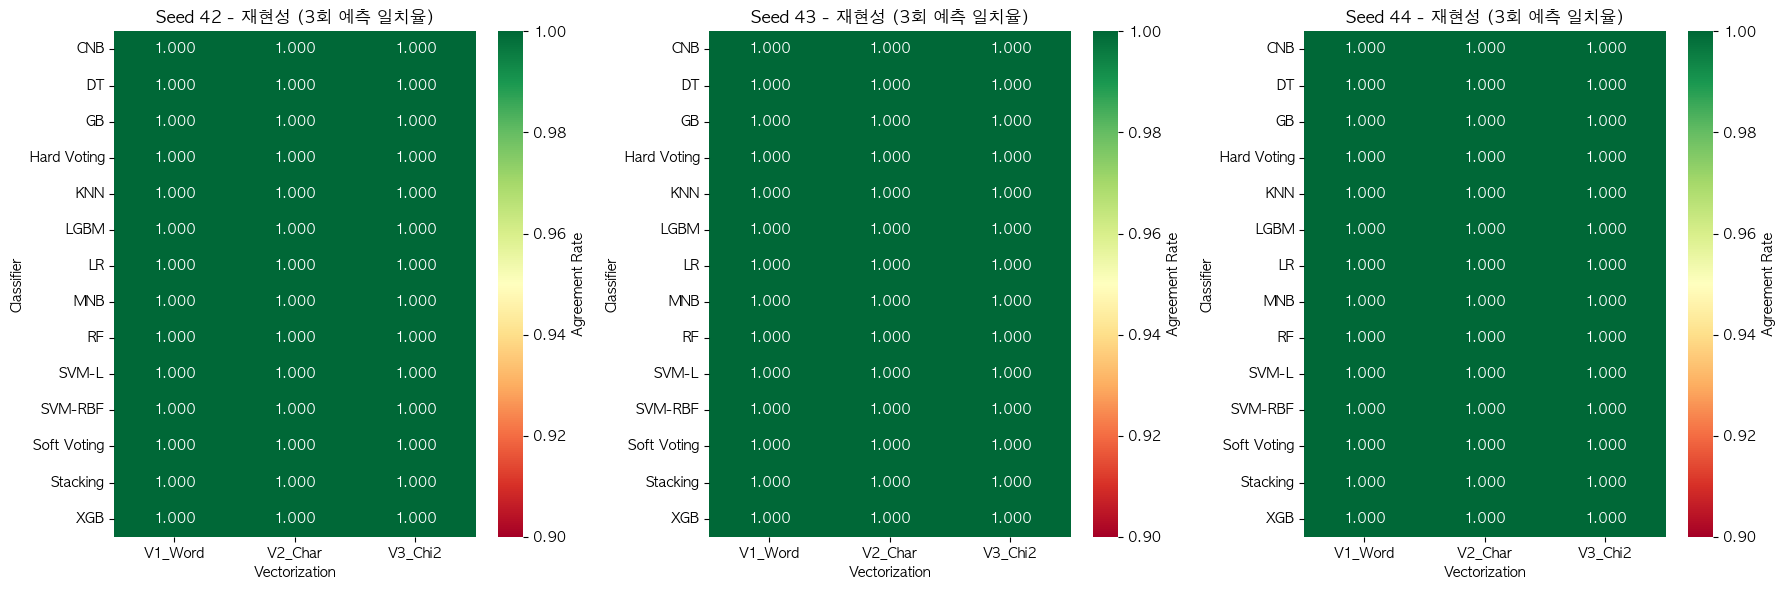

In [50]:
# 재현성 히트맵
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, train_seed in enumerate(SEEDS):
    subset = reproducibility_df[reproducibility_df['Train_Seed'] == train_seed]
    pivot = subset.pivot(index='Classifier', columns='Vectorization', values='Agreement_Rate')
    
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.9, vmax=1.0,
                ax=axes[idx], cbar_kws={'label': 'Agreement Rate'})
    axes[idx].set_title(f'Seed {train_seed} - 재현성 (3회 예측 일치율)')
    axes[idx].set_xlabel('Vectorization')
    axes[idx].set_ylabel('Classifier')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/summary/reproducibility_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

**결과 해석:** 대부분의 모델이 높은 재현성을 보이며, 이는 동일 조건에서 동일한 결과를 얻을 수 있음을 의미합니다.
재현성이 낮은 모델이 있다면 해당 모델의 내부 랜덤 요소를 확인해야 합니다.

---
## 10. 일반화 분석

### 일반화(Generalization) 분석
**일반화 능력**이란 모델이 학습에 사용하지 않은 새로운 데이터에서도 좋은 성능을 보이는 능력입니다.

여기서는 두 가지를 비교합니다:
- **Same Seed 성능**: 같은 seed로 분할된 테스트 세트 (학습 데이터와 동일한 분할)
- **Cross Seed 성능**: 다른 seed로 분할된 테스트 세트 (완전히 다른 분할)

두 성능의 차이가 작을수록 모델의 일반화 능력이 우수합니다.

In [51]:
# 같은 seed vs 다른 seed 성능 비교
print("="*70)
print("일반화 분석 결과")
print("="*70)

# 같은 seed 성능 (reproducibility_df에서)
same_seed_perf = reproducibility_df.groupby(['Vectorization', 'Classifier'])['Accuracy'].mean()

# 다른 seed 성능 (generalization_df에서)
other_seed_perf = generalization_df.groupby(['Vectorization', 'Classifier'])['Accuracy'].mean()

# 성능 차이
perf_diff = same_seed_perf - other_seed_perf
print(f"\n[Same Seed vs Other Seed 성능 차이 (Accuracy)]")
print(f"  평균 차이: {perf_diff.mean():.4f}")
print(f"  최대 차이: {perf_diff.max():.4f}")
print(f"  최소 차이: {perf_diff.min():.4f}")

일반화 분석 결과

[Same Seed vs Other Seed 성능 차이 (Accuracy)]
  평균 차이: -0.0873
  최대 차이: -0.0545
  최소 차이: -0.2268


In [52]:
# 분류기별 일반화 성능
print(f"\n[분류기별 평균 성능]")

# Same seed
same_clf = reproducibility_df.groupby('Classifier')[['Accuracy', 'F1_Macro', 'Kappa']].mean()
same_clf.columns = [f'{c}_Same' for c in same_clf.columns]

# Other seed
other_clf = generalization_df.groupby('Classifier')[['Accuracy', 'F1_Macro', 'Kappa']].mean()
other_clf.columns = [f'{c}_Other' for c in other_clf.columns]

# 결합
clf_comparison = pd.concat([same_clf, other_clf], axis=1)
clf_comparison['Acc_Drop'] = clf_comparison['Accuracy_Same'] - clf_comparison['Accuracy_Other']
clf_comparison = clf_comparison.sort_values('Accuracy_Same', ascending=False)

print(clf_comparison.round(4).to_string())


[분류기별 평균 성능]
             Accuracy_Same  F1_Macro_Same  Kappa_Same  Accuracy_Other  F1_Macro_Other  Kappa_Other  Acc_Drop
Classifier                                                                                                  
XGB                 0.8571         0.6864      0.8113          0.9344          0.8122       0.9140   -0.0773
GB                  0.8435         0.6539      0.7923          0.9387          0.8136       0.9195   -0.0952
Soft Voting         0.8299         0.7556      0.7840          0.8992          0.8577       0.8719   -0.0693
Stacking            0.8264         0.7438      0.7807          0.8993          0.8569       0.8723   -0.0729
SVM-L               0.8253         0.7452      0.7781          0.9021          0.8611       0.8755   -0.0768
Hard Voting         0.8248         0.7509      0.7778          0.8985          0.8598       0.8709   -0.0737
SVM-RBF             0.8122         0.7051      0.7620          0.8950          0.8479       0.8668   -0.0828
RF   

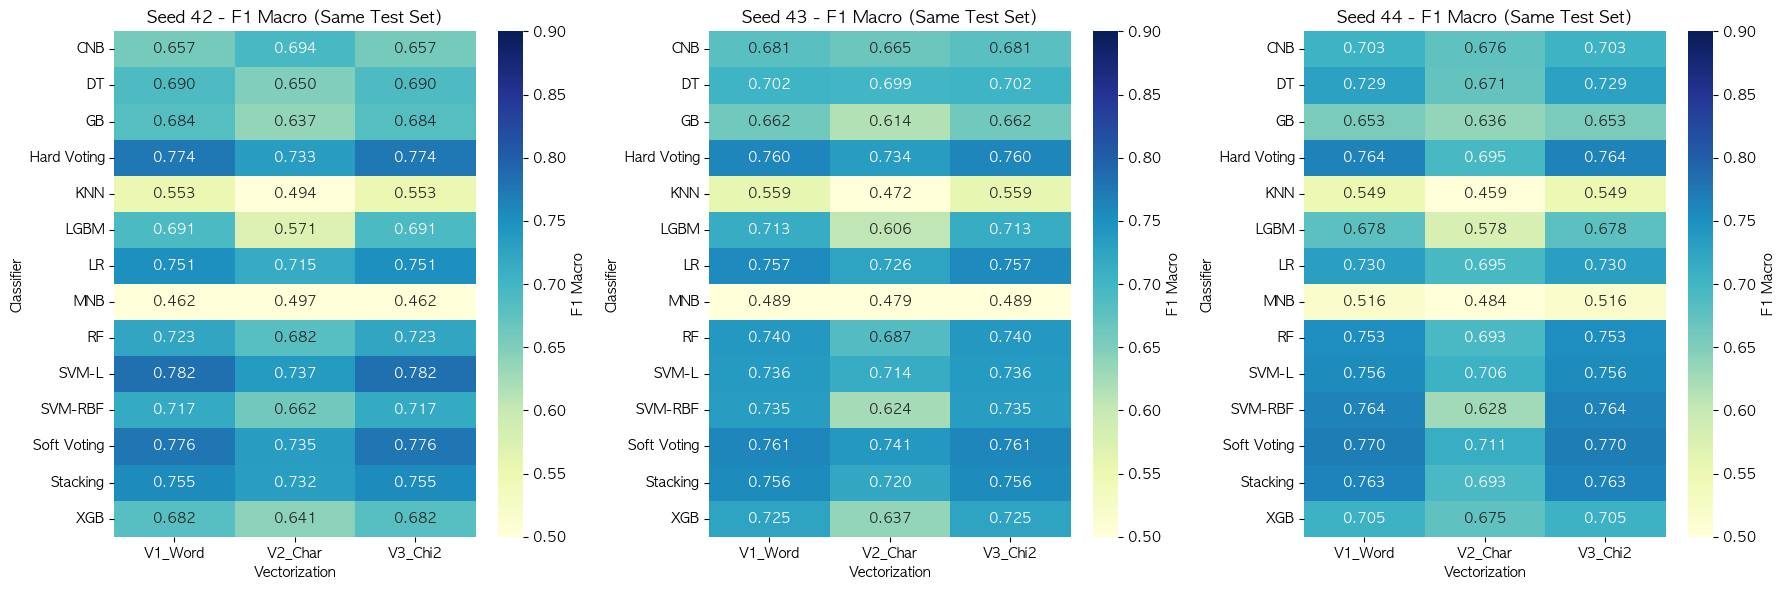

In [53]:
# 일반화 성능 히트맵 (F1 Macro)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, train_seed in enumerate(SEEDS):
    # 해당 seed로 학습한 모델의 모든 테스트 결과 (same + other)
    same_subset = reproducibility_df[reproducibility_df['Train_Seed'] == train_seed][['Vectorization', 'Classifier', 'F1_Macro']]
    same_subset = same_subset.copy()
    same_subset['Test_Type'] = 'Same'
    
    other_subset = generalization_df[generalization_df['Train_Seed'] == train_seed].groupby(
        ['Vectorization', 'Classifier']
    )['F1_Macro'].mean().reset_index()
    other_subset['Test_Type'] = 'Other_Avg'
    
    # 평균 성능으로 히트맵
    combined = pd.concat([same_subset, other_subset])
    pivot = combined.pivot_table(index='Classifier', columns=['Vectorization', 'Test_Type'], values='F1_Macro')
    
    # 단순화: Same seed F1만 표시
    pivot_same = reproducibility_df[reproducibility_df['Train_Seed'] == train_seed].pivot(
        index='Classifier', columns='Vectorization', values='F1_Macro'
    )
    
    sns.heatmap(pivot_same, annot=True, fmt='.3f', cmap='YlGnBu', vmin=0.5, vmax=0.9,
                ax=axes[idx], cbar_kws={'label': 'F1 Macro'})
    axes[idx].set_title(f'Seed {train_seed} - F1 Macro (Same Test Set)')
    axes[idx].set_xlabel('Vectorization')
    axes[idx].set_ylabel('Classifier')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/summary/performance_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [54]:
# Seed 간 성능 변동성 (Standard Deviation)
print(f"\n[Seed 간 성능 변동성 (Std)]")

# 같은 seed 평가 기준 seed별 성능
seed_variance = reproducibility_df.groupby(['Vectorization', 'Classifier'])['Accuracy'].std()
seed_variance_df = seed_variance.reset_index()
seed_variance_df.columns = ['Vectorization', 'Classifier', 'Accuracy_Std']

# 변동성이 큰 조합
print("\n변동성이 큰 조합 (상위 10개):")
print(seed_variance_df.sort_values('Accuracy_Std', ascending=False).head(10).to_string(index=False))

print("\n변동성이 작은 조합 (하위 10개):")
print(seed_variance_df.sort_values('Accuracy_Std', ascending=True).head(10).to_string(index=False))


[Seed 간 성능 변동성 (Std)]

변동성이 큰 조합 (상위 10개):
Vectorization  Classifier  Accuracy_Std
      V3_Chi2         MNB      0.022720
      V1_Word         MNB      0.022720
      V1_Word         CNB      0.020160
      V3_Chi2         CNB      0.020160
      V2_Char    Stacking      0.018775
      V2_Char          LR      0.018360
      V3_Chi2        LGBM      0.018202
      V1_Word        LGBM      0.018202
      V2_Char Soft Voting      0.016363
      V3_Chi2          RF      0.014490

변동성이 작은 조합 (하위 10개):
Vectorization Classifier  Accuracy_Std
      V2_Char        KNN      0.002404
      V3_Chi2        KNN      0.002776
      V1_Word        KNN      0.002776
      V1_Word         LR      0.004808
      V3_Chi2         LR      0.004808
      V2_Char    SVM-RBF      0.006360
      V1_Word         GB      0.006360
      V3_Chi2         GB      0.006360
      V2_Char         GB      0.006939
      V2_Char        MNB      0.007212


---
## 11. 종합 요약

### 종합 결과 정리
모든 실험 결과를 종합하여 최적의 벡터화-분류기 조합을 선정합니다.

평가 기준:
1. **성능**: F1 Macro와 Cohen's Kappa가 높은 조합
2. **안정성**: CV 표준편차가 낮은 조합
3. **재현성**: 예측 일치율이 높은 조합
4. **일반화**: Cross-seed 성능 저하가 적은 조합

In [55]:
# 최종 요약 테이블 생성
print("="*70)
print("종합 요약")
print("="*70)

# ========== 1. 벡터화 × 분류기 조합별 성능 (핵심!) ==========
print("\n" + "="*70)
print("[1] 벡터화 × 분류기 조합별 성능 (3-seed 평균)")
print("="*70)

combination_summary = reproducibility_df.groupby(['Vectorization', 'Classifier']).agg({
    'Accuracy': ['mean', 'std'],
    'F1_Macro': ['mean', 'std'],
    'Kappa': ['mean', 'std'],
    'Agreement_Rate': 'mean'
}).round(4)

combination_summary.columns = ['Acc_Mean', 'Acc_Std', 'F1_Mean', 'F1_Std', 'Kappa_Mean', 'Kappa_Std', 'Reproducibility']
combination_summary = combination_summary.reset_index()
combination_summary = combination_summary.sort_values('F1_Mean', ascending=False)

print("\n[상위 15개 조합]")
print(combination_summary.head(15).to_string(index=False))

# 최고 조합 저장
best_combination = combination_summary.iloc[0]
BEST_VECTORIZATION = best_combination['Vectorization']
BEST_CLASSIFIER = best_combination['Classifier']

print("\n" + "="*70)
print("★★★ 최고 성능 조합 ★★★")
print("="*70)
print(f"\n  벡터화: {BEST_VECTORIZATION}")
print(f"  분류기: {BEST_CLASSIFIER}")
print(f"  ----------------------------------------")
print(f"  Accuracy:  {best_combination['Acc_Mean']:.4f} (±{best_combination['Acc_Std']:.4f})")
print(f"  F1 Macro:  {best_combination['F1_Mean']:.4f} (±{best_combination['F1_Std']:.4f})")
print(f"  Kappa:     {best_combination['Kappa_Mean']:.4f} (±{best_combination['Kappa_Std']:.4f})")
print(f"  재현성:    {best_combination['Reproducibility']:.4f}")

# ========== 2. 분류기별 종합 성능 (참고용) ==========
print("\n" + "="*70)
print("[2] 분류기별 종합 성능 (모든 벡터화 평균)")
print("="*70)

summary_data = []
for clf_name in get_all_classifiers().keys():
    rep_subset = reproducibility_df[reproducibility_df['Classifier'] == clf_name]
    gen_subset = generalization_df[generalization_df['Classifier'] == clf_name]
    
    summary = {
        'Classifier': clf_name,
        'Acc_Mean': rep_subset['Accuracy'].mean(),
        'Acc_Std': rep_subset['Accuracy'].std(),
        'F1_Mean': rep_subset['F1_Macro'].mean(),
        'F1_Std': rep_subset['F1_Macro'].std(),
        'Kappa_Mean': rep_subset['Kappa'].mean(),
        'Reproducibility': rep_subset['Agreement_Rate'].mean(),
        'Gen_Acc_Mean': gen_subset['Accuracy'].mean(),
        'Gen_Acc_Drop': rep_subset['Accuracy'].mean() - gen_subset['Accuracy'].mean()
    }
    summary_data.append(summary)

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values('F1_Mean', ascending=False)

print(summary_df.round(4).to_string(index=False))

종합 요약

[1] 벡터화 × 분류기 조합별 성능 (3-seed 평균)

[상위 15개 조합]
Vectorization  Classifier  Acc_Mean  Acc_Std  F1_Mean  F1_Std  Kappa_Mean  Kappa_Std  Reproducibility
      V1_Word Soft Voting    0.8478   0.0097   0.7690  0.0079      0.8059     0.0127              1.0
      V3_Chi2 Soft Voting    0.8478   0.0097   0.7690  0.0079      0.8059     0.0127              1.0
      V1_Word Hard Voting    0.8421   0.0077   0.7661  0.0075      0.7989     0.0100              1.0
      V3_Chi2 Hard Voting    0.8421   0.0077   0.7661  0.0075      0.7989     0.0100              1.0
      V3_Chi2       SVM-L    0.8413   0.0110   0.7583  0.0230      0.7977     0.0144              1.0
      V1_Word       SVM-L    0.8413   0.0110   0.7583  0.0230      0.7977     0.0144              1.0
      V3_Chi2    Stacking    0.8454   0.0091   0.7581  0.0045      0.8036     0.0114              1.0
      V1_Word    Stacking    0.8454   0.0091   0.7581  0.0045      0.8036     0.0114              1.0
      V3_Chi2          LR    

In [56]:
# 벡터화별 종합 성능
vec_summary = []

for vec_name in VEC_NAMES:
    rep_subset = reproducibility_df[reproducibility_df['Vectorization'] == vec_name]
    gen_subset = generalization_df[generalization_df['Vectorization'] == vec_name]
    
    summary = {
        'Vectorization': vec_name,
        'Acc_Mean': rep_subset['Accuracy'].mean(),
        'Acc_Std': rep_subset['Accuracy'].std(),
        'F1_Mean': rep_subset['F1_Macro'].mean(),
        'Reproducibility': rep_subset['Agreement_Rate'].mean(),
        'Gen_Acc_Mean': gen_subset['Accuracy'].mean()
    }
    vec_summary.append(summary)

vec_summary_df = pd.DataFrame(vec_summary)
print("\n[벡터화별 종합 성능]")
print(vec_summary_df.round(4).to_string(index=False))


[벡터화별 종합 성능]
Vectorization  Acc_Mean  Acc_Std  F1_Mean  Reproducibility  Gen_Acc_Mean
      V1_Word    0.8151   0.0462   0.6978              1.0        0.8945
      V2_Char    0.7643   0.0475   0.6500              1.0        0.8673
      V3_Chi2    0.8151   0.0462   0.6978              1.0        0.8945


In [57]:
# 최종 요약 저장
combination_summary.to_csv(f'{OUTPUT_DIR}/summary/combination_summary.csv', index=False)
summary_df.to_csv(f'{OUTPUT_DIR}/summary/classifier_summary.csv', index=False)
vec_summary_df.to_csv(f'{OUTPUT_DIR}/summary/vectorization_summary.csv', index=False)

print("최종 요약 파일 저장 완료:")
print(f"  - {OUTPUT_DIR}/summary/combination_summary.csv  (★ 조합별 성능)")
print(f"  - {OUTPUT_DIR}/summary/classifier_summary.csv")
print(f"  - {OUTPUT_DIR}/summary/vectorization_summary.csv")

최종 요약 파일 저장 완료:
  - ./results/final_experiment/summary/combination_summary.csv  (★ 조합별 성능)
  - ./results/final_experiment/summary/classifier_summary.csv
  - ./results/final_experiment/summary/vectorization_summary.csv


In [58]:
# 최고 성능 조합의 일반화 성능 확인
print("="*70)
print("최고 조합의 일반화 성능")
print("="*70)

best_gen = generalization_df[
    (generalization_df['Vectorization'] == BEST_VECTORIZATION) & 
    (generalization_df['Classifier'] == BEST_CLASSIFIER)
]

print(f"\n조합: {BEST_VECTORIZATION} + {BEST_CLASSIFIER}")
print(f"\n[Same Seed 테스트 성능]")
print(f"  Accuracy:  {best_combination['Acc_Mean']:.4f}")
print(f"  F1 Macro:  {best_combination['F1_Mean']:.4f}")

print(f"\n[Other Seed 테스트 성능 (일반화)]")
print(f"  Accuracy:  {best_gen['Accuracy'].mean():.4f}")
print(f"  F1 Macro:  {best_gen['F1_Macro'].mean():.4f}")

print(f"\n[성능 저하]")
print(f"  Accuracy Drop: {best_combination['Acc_Mean'] - best_gen['Accuracy'].mean():.4f}")
print(f"  F1 Drop:       {best_combination['F1_Mean'] - best_gen['F1_Macro'].mean():.4f}")

최고 조합의 일반화 성능

조합: V1_Word + Soft Voting

[Same Seed 테스트 성능]
  Accuracy:  0.8478
  F1 Macro:  0.7690

[Other Seed 테스트 성능 (일반화)]
  Accuracy:  0.9083
  F1 Macro:  0.8643

[성능 저하]
  Accuracy Drop: -0.0605
  F1 Drop:       -0.0953


In [59]:
# 실험 설정 및 최고 조합 저장
experiment_config = {
    'Date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'Seeds': SEEDS,
    'Vectorizations': VEC_NAMES,
    'N_Classifiers': len(get_all_classifiers()),
    'Classifiers': list(get_all_classifiers().keys()),
    'CV_Folds': N_FOLDS,
    'CV_Method': 'Stratified K-Fold',
    'N_Reproducibility_Repeats': 3,
    'V3_Chi2_K': V3_K,
    'Total_Combinations': len(SEEDS) * len(VEC_NAMES) * len(get_all_classifiers()),
    'Best_Combination': {
        'Vectorization': BEST_VECTORIZATION,
        'Classifier': BEST_CLASSIFIER,
        'Accuracy_Mean': float(best_combination['Acc_Mean']),
        'Accuracy_Std': float(best_combination['Acc_Std']),
        'F1_Macro_Mean': float(best_combination['F1_Mean']),
        'F1_Macro_Std': float(best_combination['F1_Std']),
        'Kappa_Mean': float(best_combination['Kappa_Mean']),
        'Reproducibility': float(best_combination['Reproducibility'])
    }
}

with open(f'{OUTPUT_DIR}/summary/experiment_config.json', 'w') as f:
    json.dump(experiment_config, f, indent=2, ensure_ascii=False)

print(f"실험 설정 저장: {OUTPUT_DIR}/summary/experiment_config.json")

# 최종 출력
print("\n" + "="*70)
print("실험 완료! (Stratified 10-Fold CV)")
print("="*70)
print(f"\n★ 최고 조합: {BEST_VECTORIZATION} + {BEST_CLASSIFIER}")
print(f"  - F1 Macro: {best_combination['F1_Mean']:.4f} (±{best_combination['F1_Std']:.4f})")
print(f"  - 이 조합을 다른 분류 기법(BERT, LLM 등)과 비교하세요.")
print(f"\n완료 시간: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

실험 설정 저장: ./results/final_experiment/summary/experiment_config.json

실험 완료! (Stratified 10-Fold CV)

★ 최고 조합: V1_Word + Soft Voting
  - F1 Macro: 0.7690 (±0.0079)
  - 이 조합을 다른 분류 기법(BERT, LLM 등)과 비교하세요.

완료 시간: 2026-01-28 17:16:34
